# Experiment 4: Dual-Channel Interpretability Analysis
Extracts and visualizes the dual-channel attention weights (Graph & Sequence) to interpret the pharmacological features identified by the model. We use the best model results from Experiment 2.


In [1]:
# Install required dependencies (Kaggle / Colab compatibility)
!pip install -q numpy rdkit matplotlib scikit-learn torch seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 112.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

In [2]:
!pip install "transformers<4.35.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 21.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fo

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from rdkit import Chem, RDLogger
from rdkit.Chem.Draw import SimilarityMaps
from transformers import AutoModel, AutoTokenizer

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
os.environ['PYTHONHASHSEED'] = '42'
import random
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

MOLFORMER_NAME = "/kaggle/input/models/konstantinboyko/molformer-xl-both-10pct-ibm-research/transformers/default/1"
MPNN_DIM = 64
MOLFORMER_DIM = 768

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = "/kaggle/working" if os.path.exists("/kaggle/input") else "results/interpretability"
os.makedirs(out_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'serif'

# Target Molecules for Interpretability
TARGET_MOLECULES = {
    "Caffeine (BBB+)": "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Nicotine (BBB+)": "CN1CCCC1c2cccnc2",
    "Penicillin G (BBB-)": "CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O",
    "Dopamine (BBB-)": "c1cc(c(cc1CCN)O)O"
}


## 1. Feature Engineering


In [4]:
class MolecularPropertyEncoder:
    def __init__(self, permitted_value_sets):
        self.total_dimensions = 0
        self.property_mapping_dict = {}
        for prop_id, permitted_values in permitted_value_sets.items():
            ordered = sorted(list(permitted_values))
            mapping = dict(zip(ordered, range(self.total_dimensions, len(ordered) + self.total_dimensions)))
            self.property_mapping_dict[prop_id] = mapping
            self.total_dimensions += len(ordered)
    def transform_to_vector(self, component):
        vec = np.zeros((self.total_dimensions,))
        for prop_id, mapping in self.property_mapping_dict.items():
            val = getattr(self, prop_id)(component)
            if val in mapping: vec[mapping[val]] = 1.0
        return vec

class AtomicPropertyEncoder(MolecularPropertyEncoder):
    def symbol(self, a): return a.GetSymbol()
    def n_valence(self, a): return a.GetTotalValence()
    def n_hydrogens(self, a): return a.GetTotalNumHs()
    def hybridization(self, a): return a.GetHybridization().name.lower()

class BondPropertyEncoder(MolecularPropertyEncoder):
    def __init__(self, s):
        super().__init__(s); self.total_dimensions += 1
    def transform_to_vector(self, bond):
        vec = np.zeros((self.total_dimensions,))
        if bond is None: vec[-1] = 1.0; return vec
        return super().transform_to_vector(bond)
    def bond_type(self, b): return b.GetBondType().name.lower()
    def conjugated(self, b): return b.GetIsConjugated()

atom_enc = AtomicPropertyEncoder({
    "symbol": {"B","Br","C","Ca","Cl","F","H","I","N","Na","O","P","S"}, 
    "n_valence": {0,1,2,3,4,5,6}, 
    "n_hydrogens": {0,1,2,3,4}, 
    "hybridization": {"s","sp","sp2","sp3"}
})
bond_enc = BondPropertyEncoder({
    "bond_type": {"single","double","triple","aromatic"}, 
    "conjugated": {True, False}
})

def smiles_to_mol(s):
    mol = Chem.MolFromSmiles(s, sanitize=False)
    res = Chem.SanitizeMol(mol, catchErrors=True)
    if res != Chem.SanitizeFlags.SANITIZE_NONE: 
        Chem.SanitizeMol(mol, sanitizeOps=Chem.SanitizeFlags.SANITIZE_ALL ^ res)
    Chem.AssignStereochemistry(mol, cleanIt=True, force=True)
    return mol

def mol_to_graph(mol):
    atom_feats, bond_feats, pairs = [], [], []
    for atom in mol.GetAtoms():
        atom_feats.append(atom_enc.transform_to_vector(atom))
        idx = atom.GetIdx()
        pairs.append([idx, idx])
        bond_feats.append(bond_enc.transform_to_vector(None))
        for nb in atom.GetNeighbors():
            nb_idx = nb.GetIdx()
            bond = mol.GetBondBetweenAtoms(idx, nb_idx)
            pairs.append([idx, nb_idx])
            bond_feats.append(bond_enc.transform_to_vector(bond))
    return np.array(atom_feats), np.array(bond_feats), np.array(pairs)


## 2. Interpretable Architecture Blocks


In [5]:
class EdgeProcessor(nn.Module):
    def __init__(self, atom_dim, bond_dim):
        super().__init__()
        self.linear = nn.Linear(bond_dim, atom_dim)
    def forward(self, atom_f, bond_f, conn):
        merged = self.linear(bond_f) * atom_f[conn[:, 1]]
        n_atoms = atom_f.size(0)
        out = torch.zeros(n_atoms, merged.size(1), device=atom_f.device, dtype=atom_f.dtype)
        out.scatter_add_(0, conn[:, 0].unsqueeze(-1).expand(-1, merged.size(1)), merged)
        return out

class MessagePassing(nn.Module):
    def __init__(self, atom_dim, bond_dim, hidden, steps=4):
        super().__init__(); self.steps = steps; self.edge = EdgeProcessor(atom_dim, bond_dim)
        self.pad_len = max(0, hidden - atom_dim); self.gru = nn.GRUCell(hidden, hidden)
    def forward(self, atom_f, bond_f, conn):
        state = F.pad(atom_f, (0, self.pad_len)) if self.pad_len > 0 else atom_f
        for _ in range(self.steps):
            msg = self.edge(atom_f, bond_f, conn)
            msg = F.pad(msg, (0, self.pad_len)) if self.pad_len > 0 else msg
            state = self.gru(msg, state)
        return state

class InterpretableAttentionReadout(nn.Module):
    def __init__(self, dim=64, heads=8, ff=512):
        super().__init__()
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(dim, ff), nn.ReLU(), nn.Linear(ff, dim))
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
    def forward(self, feats, batch_idx):
        bs = int(batch_idx.max().item()) + 1
        parts, counts = [], []
        for i in range(bs):
            m = (batch_idx == i)
            if m.any(): parts.append(feats[m]); counts.append(parts[-1].size(0))
        if not parts: return torch.zeros(0, feats.size(1), device=feats.device), None
        mx = max(counts); d = feats.size(1); padded = []
        for p in parts:
            if p.size(0) < mx: padded.append(torch.cat([p, torch.zeros(mx - p.size(0), d, device=p.device)]))
            else: padded.append(p)
        x = torch.stack(padded); valid = (x != 0).any(dim=-1)
        
        # EXTRACT ATTENTION WEIGHTS (need_weights=True)
        att_out, att_weights = self.mha(x, x, x, key_padding_mask=~valid, need_weights=True)
        
        x2 = self.ln1(x + att_out); x3 = self.ln2(x2 + self.ff(x2))
        mask = valid.unsqueeze(-1).float()
        return (x3 * mask).sum(1) / mask.sum(1).clamp(min=1), att_weights

class InterpretableMolGraphBBB(nn.Module):
    def __init__(self, atom_dim, bond_dim, molformer):
        super().__init__()
        self.mp = MessagePassing(atom_dim, bond_dim, MPNN_DIM)
        self.readout = InterpretableAttentionReadout(MPNN_DIM)
        self.molformer = molformer
        for p in self.molformer.parameters(): p.requires_grad = False
        self.seq_proj = nn.Sequential(nn.Linear(MOLFORMER_DIM, MPNN_DIM), nn.LayerNorm(MPNN_DIM), nn.ReLU())

        self.head = nn.Sequential(nn.Linear(MPNN_DIM * 2, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 1), nn.Sigmoid())

    def forward(self, a, b, c, ba, ids, mask):
        g, graph_att_weights = self.readout(self.mp(a, b, c), ba)
        with torch.no_grad():
            # EXTRACT MOLFORMER ATTENTIONS
            mol_out = self.molformer(input_ids=ids, attention_mask=mask, output_attentions=True)
            s = mol_out.last_hidden_state.mean(dim=1)
            seq_attentions = mol_out.attentions # Tuple of (layer) attentions: (batch, heads, seq_len, seq_len)
        
        s_proj = self.seq_proj(s)

        z = torch.cat([g, s_proj], dim=-1)
        pred = self.head(z)
        return pred, graph_att_weights, seq_attentions


## 3. Main Analysis
Load the model weights from Experiment 2 and analyze the attention maps for selected molecules.


Kaggle environment detected. Found model at /kaggle/input/notebooks/shixinguo/test2-bbbp/results/best_model_MolGraph-BBB.pt
Successfully loaded model weights from /kaggle/input/notebooks/shixinguo/test2-bbbp/results/best_model_MolGraph-BBB.pt

Analyzing Caffeine (BBB+): CN1C=NC2=C1C(=O)N(C(=O)N2C)C


Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting

-> Predicted Permeability Probability: 0.9712

-> Saved Graph Attention Map to /kaggle/working/Caffeine_graph_attn.png


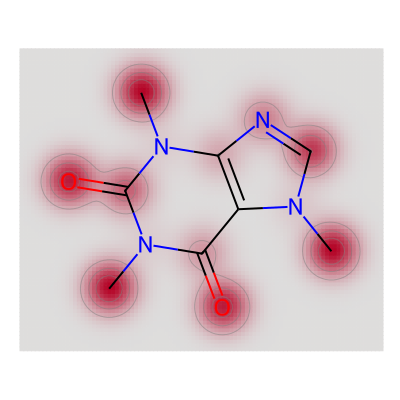

Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting


-> Top 5 Sequence Tokens with Highest Attention:
     Token: '2    ' | Weight: 0.0638
     Token: 'N    ' | Weight: 0.0591
     Token: '2    ' | Weight: 0.0574
     Token: '1    ' | Weight: 0.0573
     Token: 'N    ' | Weight: 0.0453

Analyzing Nicotine (BBB+): CN1CCCC1c2cccnc2
-> Predicted Permeability Probability: 0.9403

-> Saved Graph Attention Map to /kaggle/working/Nicotine_graph_attn.png


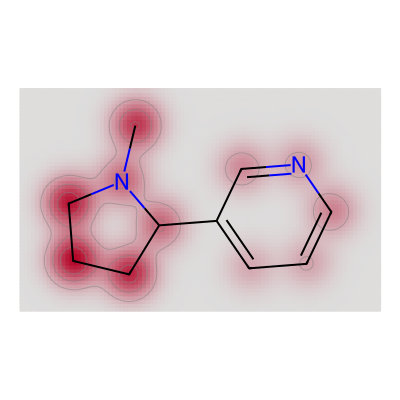

Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting


-> Top 5 Sequence Tokens with Highest Attention:
     Token: '<eos>' | Weight: 0.0969
     Token: '1    ' | Weight: 0.0942
     Token: 'C    ' | Weight: 0.0827
     Token: 'N    ' | Weight: 0.0702
     Token: 'c    ' | Weight: 0.0701

Analyzing Penicillin G (BBB-): CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O


Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.


-> Predicted Permeability Probability: 0.0275

-> Saved Graph Attention Map to /kaggle/working/Penicillin_graph_attn.png


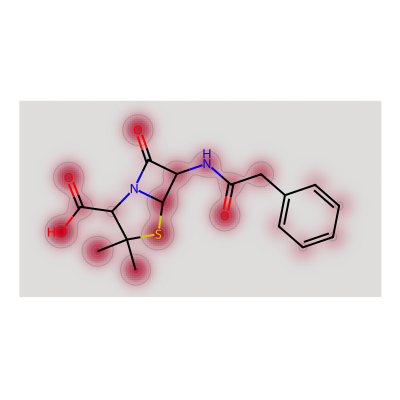

Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting attentions in linear attention negates the efficiency gains! Only use for visualization/debugging.
Outputting


-> Top 5 Sequence Tokens with Highest Attention:
     Token: 'S    ' | Weight: 0.0447
     Token: 'N    ' | Weight: 0.0444
     Token: 'C    ' | Weight: 0.0413
     Token: '2    ' | Weight: 0.0405
     Token: 'N    ' | Weight: 0.0404

Analyzing Dopamine (BBB-): c1cc(c(cc1CCN)O)O
-> Predicted Permeability Probability: 0.9294

-> Saved Graph Attention Map to /kaggle/working/Dopamine_graph_attn.png


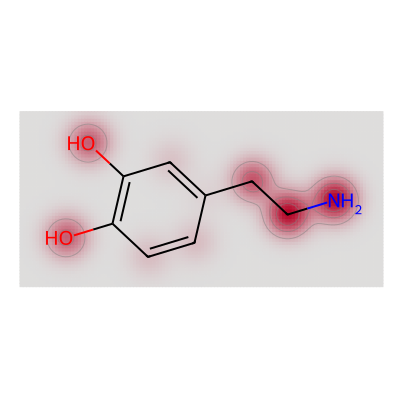


-> Top 5 Sequence Tokens with Highest Attention:
     Token: '(    ' | Weight: 0.0814
     Token: '(    ' | Weight: 0.0789
     Token: 'N    ' | Weight: 0.0718
     Token: '<bos>' | Weight: 0.0626
     Token: 'O    ' | Weight: 0.0609


In [6]:
tokenizer = AutoTokenizer.from_pretrained(MOLFORMER_NAME, trust_remote_code=True)
molformer_base = AutoModel.from_pretrained(MOLFORMER_NAME, trust_remote_code=True)

# Dummy atom/bond dim from a real molecule to initialize model
dummy_a, dummy_b, _ = mol_to_graph(smiles_to_mol("C"))
atom_dim = dummy_a.shape[1]
bond_dim = dummy_b.shape[1]

model = InterpretableMolGraphBBB(atom_dim, bond_dim, molformer_base).to(device)

weight_path = "/kaggle/input/notebooks/shixinguo/test2-bbbp/results/best_model_MolGraph-BBB.pt"
import glob
if os.path.exists('/kaggle/input'):
    kaggle_models = glob.glob('/kaggle/input/**/best_model_MolGraph-BBB.pt', recursive=True)
    if kaggle_models:
        weight_path = kaggle_models[0]
        print(f"Kaggle environment detected. Found model at {weight_path}")
if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Successfully loaded model weights from {weight_path}")
else:
    print(f"[WARNING] {weight_path} not found! Using random weights.")

model.eval()

from IPython.display import Image, display

for name, smiles in TARGET_MOLECULES.items():
    print(f"\n" + "="*50)
    print(f"Analyzing {name}: {smiles}")
    print("="*50)
    mol = smiles_to_mol(smiles)
    a, b, c = mol_to_graph(mol)
    
    a_t = torch.tensor(a, dtype=torch.float32).to(device)
    b_t = torch.tensor(b, dtype=torch.float32).to(device)
    c_t = torch.tensor(c, dtype=torch.long).to(device)
    ba_t = torch.zeros(a.shape[0], dtype=torch.long).to(device)
    
    tok_out = tokenizer([smiles], return_tensors="pt", padding=True, truncation=True, max_length=202)
    ids = tok_out["input_ids"].to(device)
    mask = tok_out["attention_mask"].to(device)
    
    with torch.no_grad():
        pred, graph_attn, seq_attn = model(a_t, b_t, c_t, ba_t, ids, mask)
    
    print(f"-> Predicted Permeability Probability: {pred.item():.4f}\n")
    
    # 1. Graph Channel Attention Processing
    g_weights = graph_attn[0].mean(dim=0).cpu().numpy()
    if g_weights.max() > g_weights.min():
        g_weights = (g_weights - g_weights.min()) / (g_weights.max() - g_weights.min())
    
    n_atoms = mol.GetNumAtoms()
    g_weights = g_weights[:n_atoms]
    
    try:
        from rdkit.Chem.Draw import rdMolDraw2D
        safe_name = name.split()[0]
        save_path = os.path.join(out_dir, f"{safe_name}_graph_attn.png")
        
        d = rdMolDraw2D.MolDraw2DCairo(400, 400)
        weights_list = [float(w) for w in g_weights]
        SimilarityMaps.GetSimilarityMapFromWeights(
            mol, weights_list, draw2d=d, colorMap='coolwarm', contourLines=5, 
            alpha=0.25
        )
        d.FinishDrawing()
        
        with open(save_path, 'wb') as f:
            f.write(d.GetDrawingText())
            
        print(f"-> Saved Graph Attention Map to {save_path}")
        display(Image(filename=save_path))
    except Exception as e:
        print(f"-> [Warning] RDKit plotting failed: {e}")

    # 2. Sequence Channel Attention Processing
    last_layer_attn = seq_attn[-1][0]
    s_weights = last_layer_attn.mean(dim=0).mean(dim=0).cpu().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(ids[0])
    print("\n-> Top 5 Sequence Tokens with Highest Attention:")
    
    token_weights = [(t, w) for t, w in zip(tokens, s_weights) if t not in ['<s>', '</s>', '<pad>']]
    token_weights.sort(key=lambda x: x[1], reverse=True)
    
    for t, w in token_weights[:5]:
        print(f"     Token: '{t:<5s}' | Weight: {w:.4f}")
